In [1]:
import setup
from importlib import reload
reload(setup)
from setup import *

# 1D Fickian diffusion 
henry_constant = 9.3e-4 * 1000 # mol/m^3/atm for CO in water at 293.15K 
diffusion_coefficient = 1.91e-9 # m2/s for CO in water at 293.15K 
A_site = F * 1e-4 / (210e-6 * N_A) # Surface area of a single Pt site: 1cm2 = 210uC (HUPD)
delta_BL_micron = 1e-6 # Setting the denominator to 1 micron to allow for delta_BL to be in microns
k1_fick = diffusion_coefficient * henry_constant * N_A * A_site / delta_BL_micron
log_k1_fick = np.log(k1_fick)

# ER 2 

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.41,15
,3000,0,0.41,15
,3000,0,0.37,15
,3000,0,0.32,15


Computed from 4000 posterior samples and 2324 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  4503.18    63.54
p_loo       22.56        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     2324  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



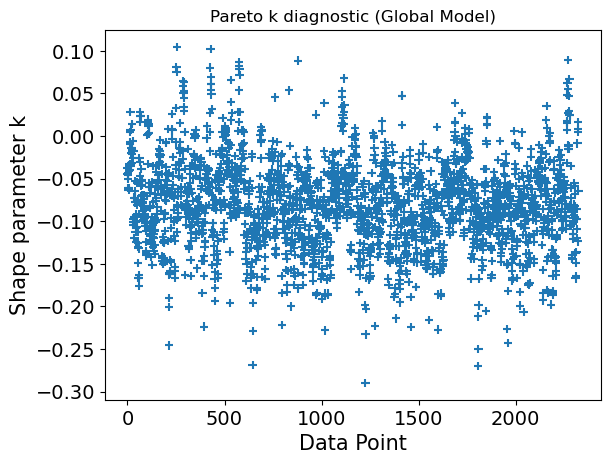

In [2]:
with pm.Model() as ER_2:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH- -> COOH* + (e-) (RDS)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)   
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2) # at 0V_SHE

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    Gact2 = Gact2_0 - beta_2*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH = log_K4 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_Q_ideal = pt.logsumexp(pt.stack([zeros, term_CO, term_OH]), axis=0)
    theta_CO = pm.Deterministic('theta_CO', pt.minimum(0.8, pt.exp(term_CO - log_Q_ideal)))
    slack = 1.0 - theta_CO
    log_Q_other = pt.logsumexp(pt.stack([zeros, term_OH]), axis=0)
    theta_OH = pm.Deterministic('theta_OH', slack * pt.exp(term_OH - log_Q_other))
    theta_empty = pm.Deterministic('theta_empty', slack * pt.exp(-log_Q_other))

    # Rate expression
    log_rate = log_k2 + pt.log(theta_CO) + np.log(C_KOH_in)
    rate = observables(log_rate) 

trace_ER_2, loo_ER_2 = fit_and_evaluate(ER_2)

            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0 -0.102  0.001  -0.105   -0.099        0.0      0.0    2184.0    2149.0    1.0
deltaG4_0  0.052  0.009   0.035    0.068        0.0      0.0    1797.0    2021.0    1.0
Gact2_0    0.749  0.000   0.748    0.749        0.0      0.0    2491.0    2209.0    1.0
beta_2     0.249  0.004   0.241    0.255        0.0      0.0    2177.0    2471.0    1.0
sigma_rel  0.157  0.007   0.145    0.169        0.0      0.0    1814.0    2130.0    1.0
exponent   0.557  0.013   0.531    0.581        0.0      0.0    1655.0    2165.0    1.0


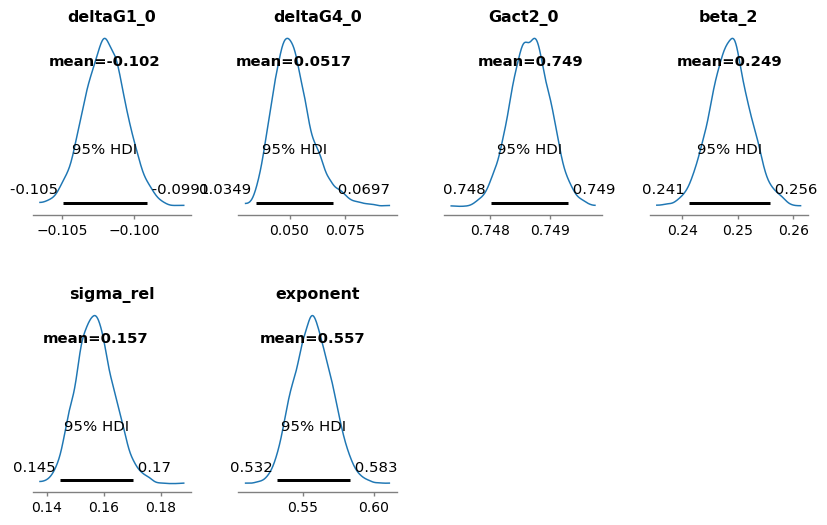

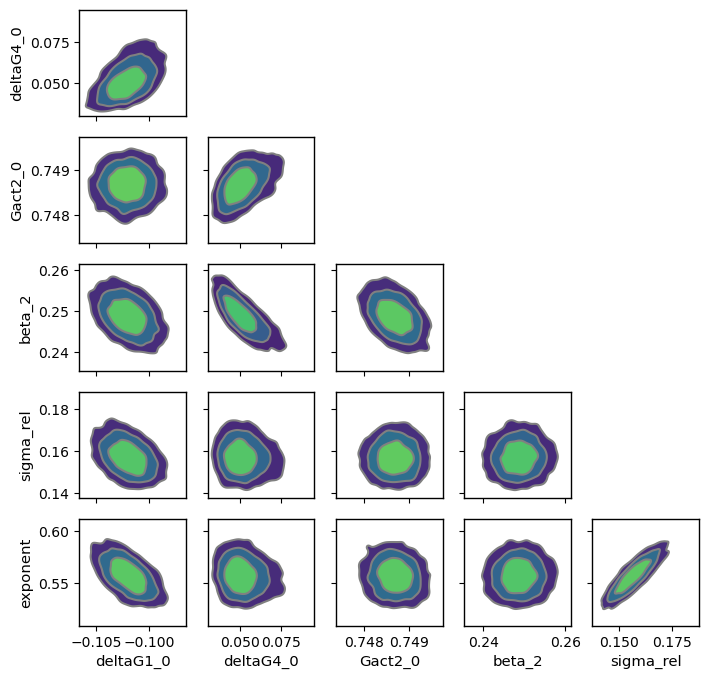

Sampling: [rate]


rate: 0.823


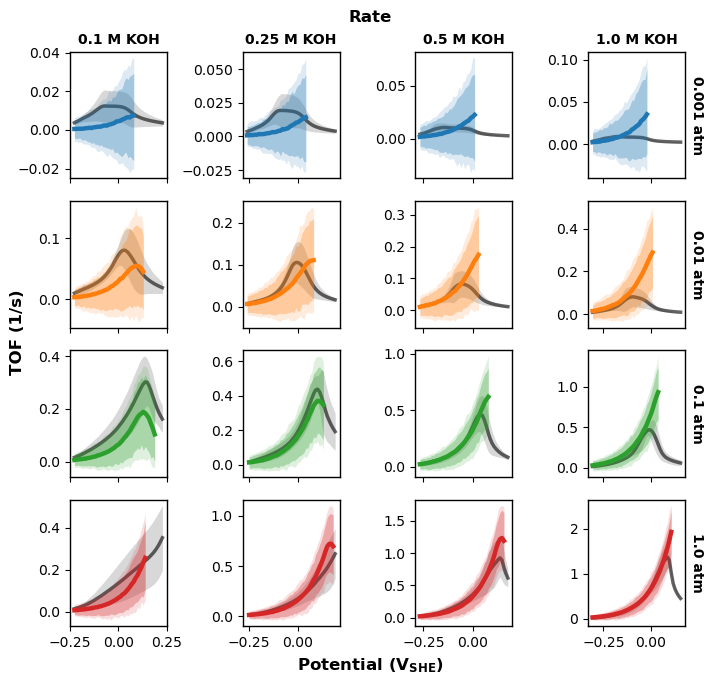

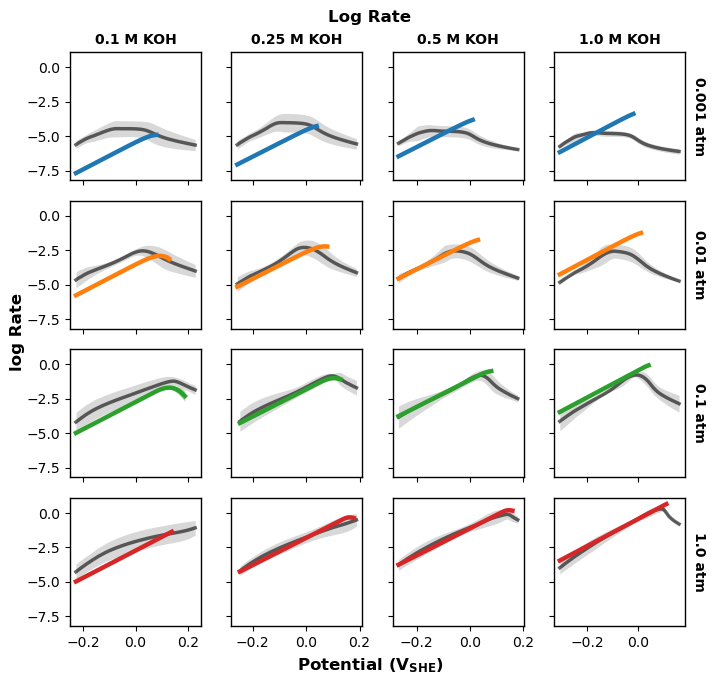

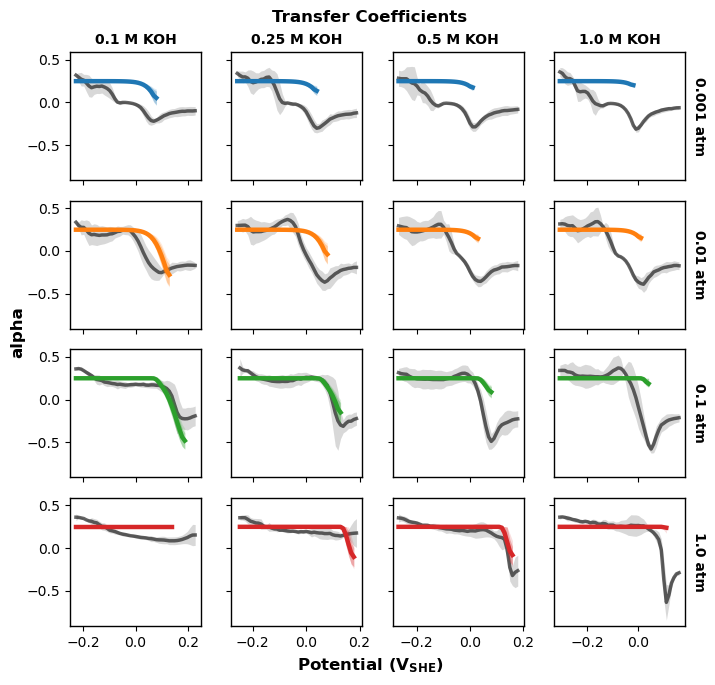

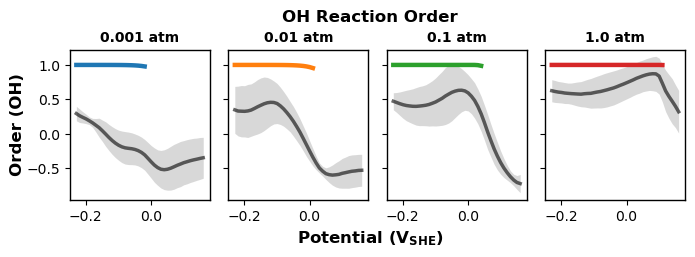

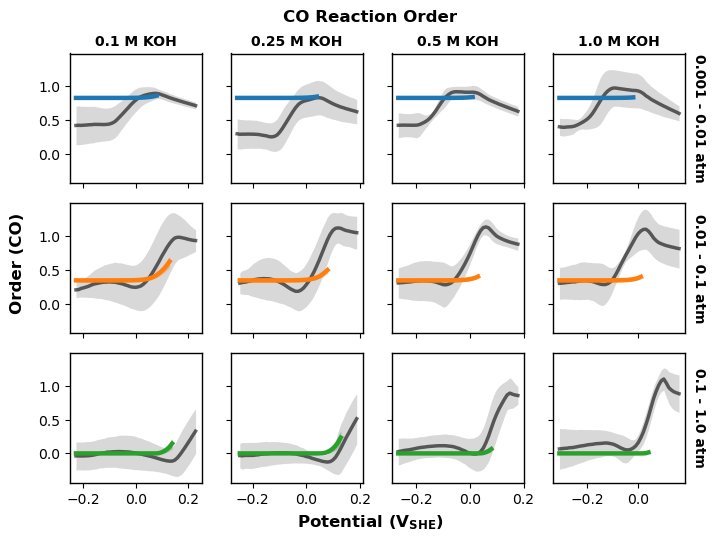

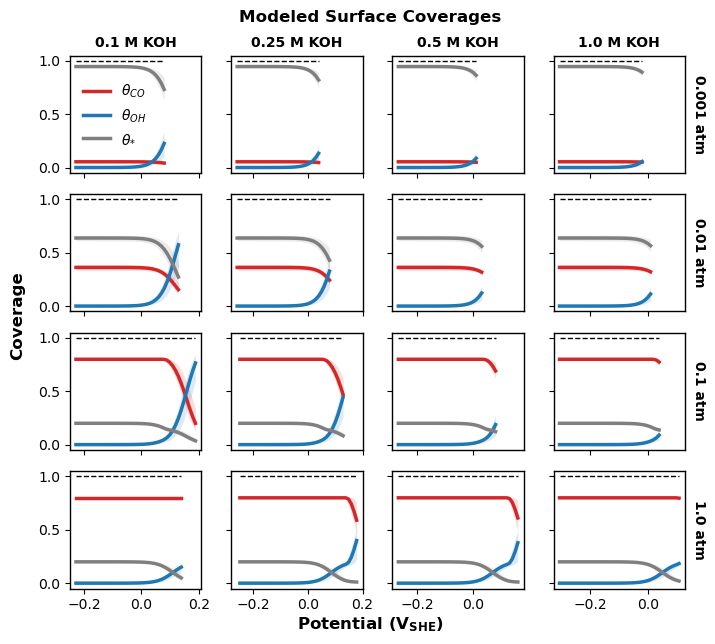

In [3]:
ppc_ER_2 = plot_posteriors(trace_ER_2, ER_2, plot_target)
plot_model_fits(trace_ER_2, ppc_ER_2); plot_coverages(trace_ER_2)

# ER 1 2

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.51,15
,3000,0,0.50,15
,3000,0,0.48,15
,3000,0,0.48,7


Computed from 4000 posterior samples and 2324 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  5170.31    72.60
p_loo        8.23        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     2324  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



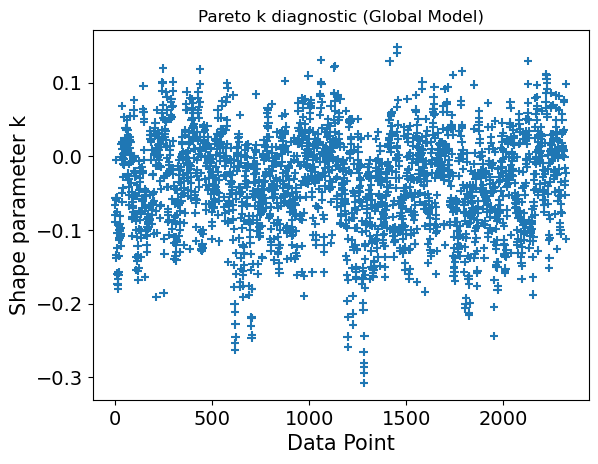

In [4]:
with pm.Model() as ER_1_2: 
    '''
    1. CO + * -> CO* (Fick) (Irr) (SSA)
    2. CO* + OH- -> COOH* + (e-) (SSA)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.1) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)
    Gact2_0 = pm.Normal('Gact2_0', mu=0.75, sigma=0.1) # at 0V_SHE
    delta_BL = pm.TruncatedNormal('delta_BL', mu=10, sigma=5, lower=0) # in microns

    # Thermodynamics 
    deltaG4 = deltaG4_0 - E_in
    Gact2 = Gact2_0 - beta_2*E_in
    log_K4 = -deltaG4/(kb_eV*T)
    log_k1 = log_k1_fick - pt.log(delta_BL)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_k1 + np.log(P_CO_in) - (log_k2 + np.log(C_KOH_in))
    term_OH = log_K4 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH]), axis=0)
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))
    theta_empty = pm.Deterministic('theta_empty', pt.exp(log_theta))

    # Rate expression
    log_rate_model = log_k2 + np.log(C_KOH_in) + log_theta_CO 
    log_rate = observables(log_rate_model) 

    phi_fick = pm.Deterministic('phi_fick', pt.exp(log_k1 + np.log(P_CO_in) - log_rate_model))

trace_ER_1_2, loo_ER_1_2 = fit_and_evaluate(ER_1_2)

            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG4_0  0.089  0.003   0.085    0.094      0.000    0.000    3425.0    2829.0    1.0
Gact2_0    0.747  0.000   0.746    0.748      0.000    0.000    2382.0    2465.0    1.0
beta_2     0.277  0.003   0.271    0.283      0.000    0.000    2923.0    2349.0    1.0
delta_BL   8.796  0.198   8.401    9.144      0.003    0.003    3880.0    2743.0    1.0
sigma_rel  0.214  0.010   0.197    0.234      0.000    0.000    1745.0    2263.0    1.0
exponent   0.802  0.015   0.773    0.830      0.000    0.000    1741.0    2242.0    1.0


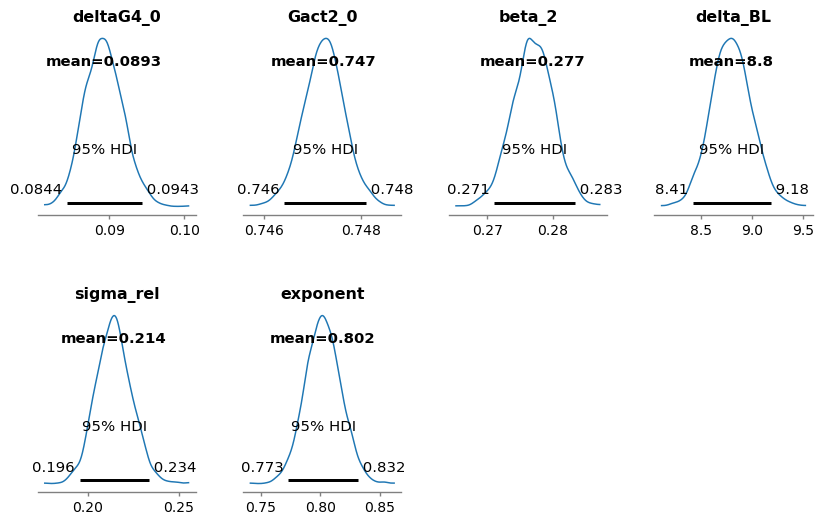

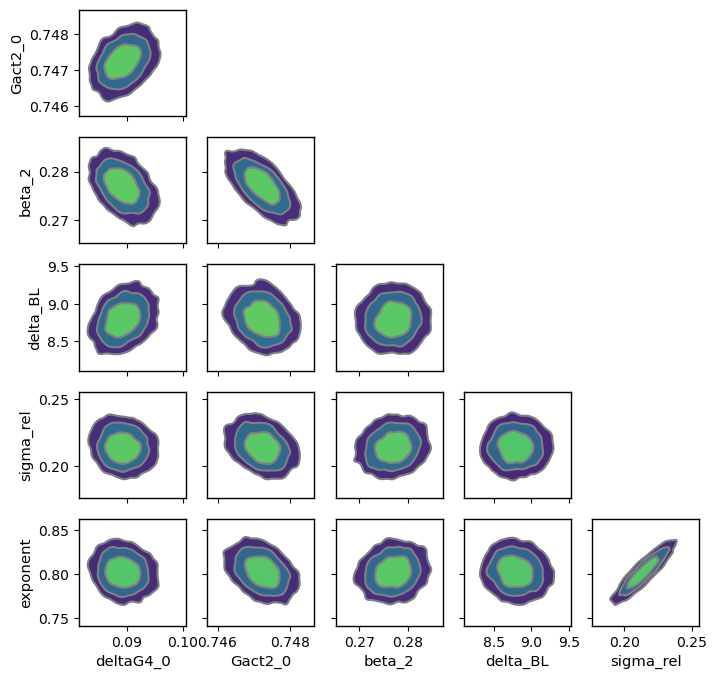

Sampling: [rate]


rate: 0.831


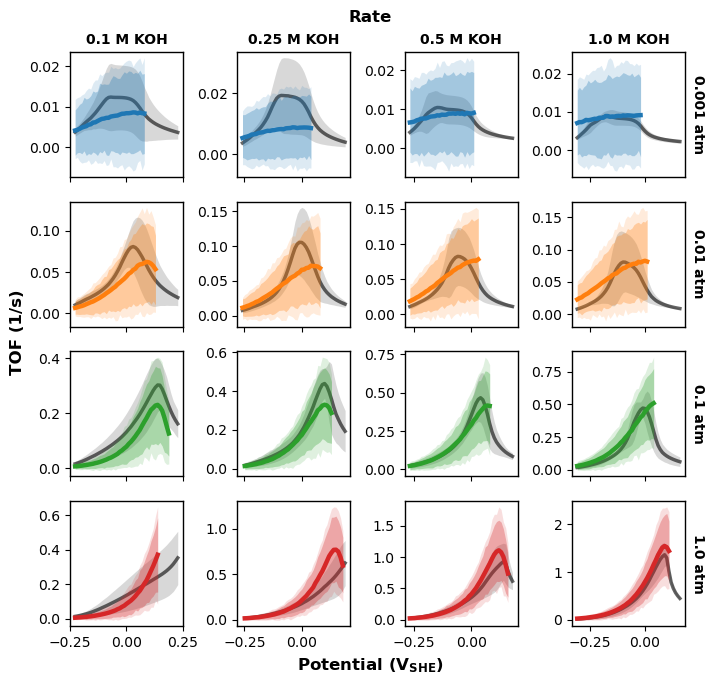

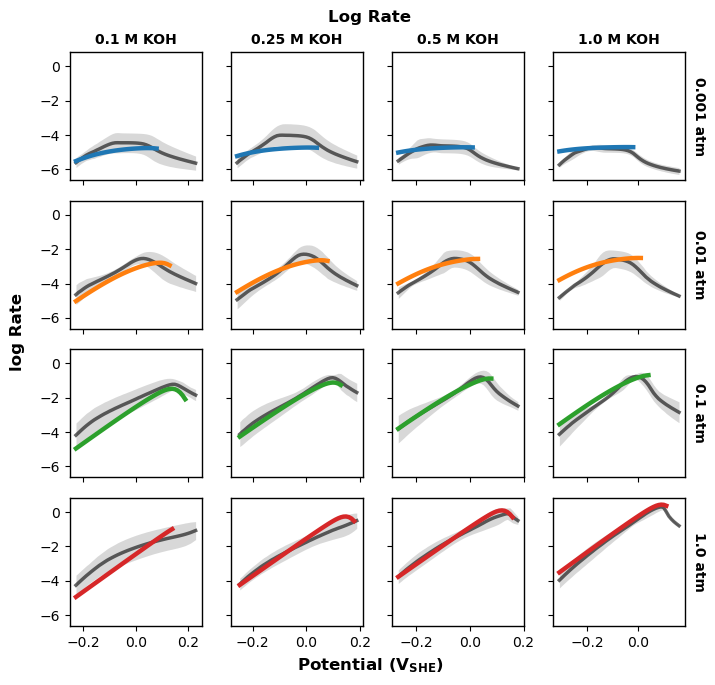

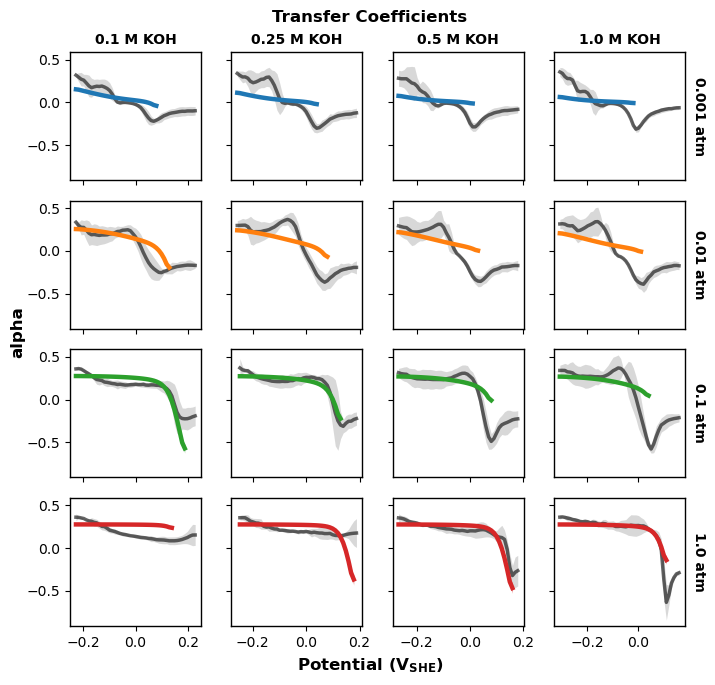

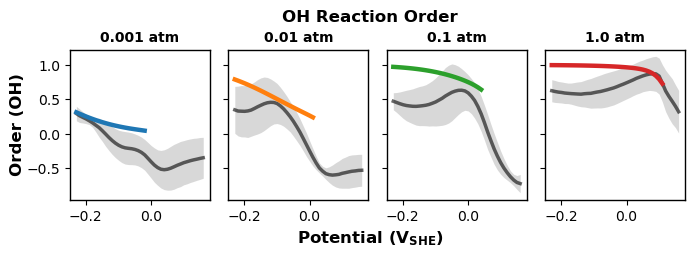

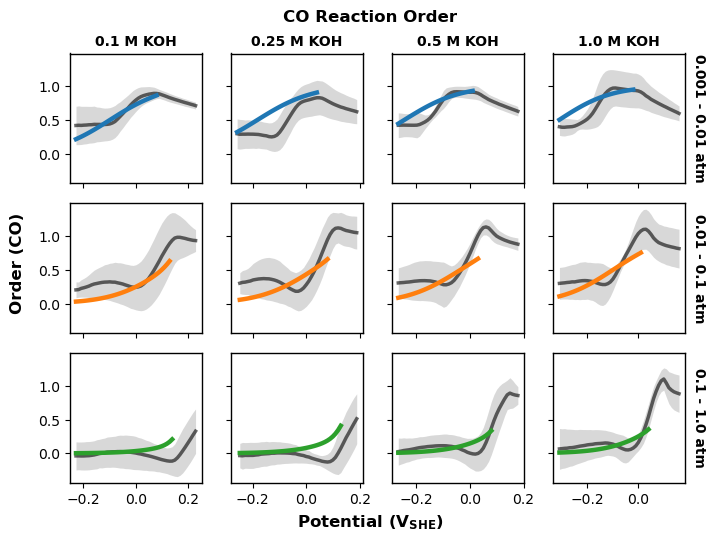

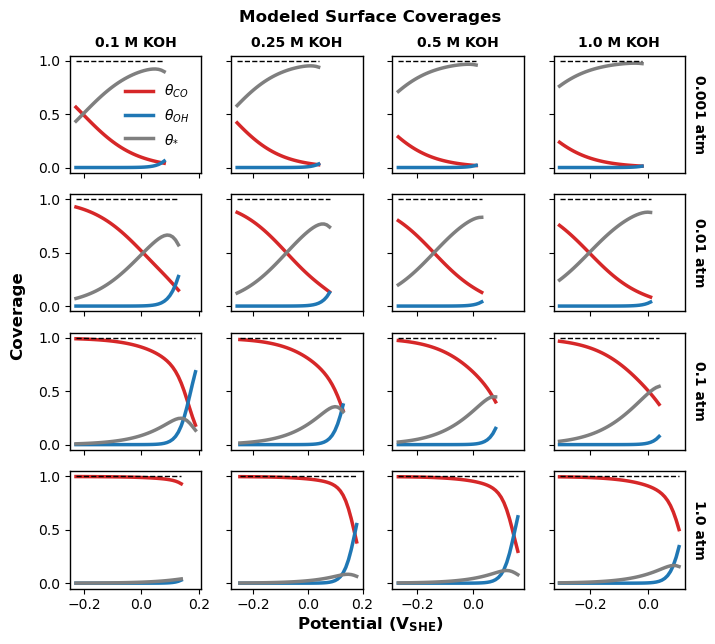

In [5]:
ppc_ER_1_2 = plot_posteriors(trace_ER_1_2, ER_1_2, plot_target)
plot_model_fits(trace_ER_1_2, ppc_ER_1_2); plot_coverages(trace_ER_1_2)